# The Curse of Dimensionality — From Geometry to MNIST

**Part I — the geometry** (pure math): what goes wrong in a high-dimensional *cube* and *sphere*.
**Part II — real data** (MNIST, $784$ dimensions): how much of the curse actually bites, and the "blessing of dimensionality."

## Contents

**Part I — The geometry of high dimensions**
1. The intuition that fails — $9$ points
2. The spiky cube — distance to the corner grows like $\sqrt{d}$
3. Volume flees to a thin shell near the surface
4. The vanishing sphere — $\mathrm{vol(ball)}/\mathrm{vol(cube)} \to 0$
5. Exponential data hunger — $5^d$
6. Everything becomes orthogonal — $\mathbb{E}[\cos]=0,\ \mathrm{Var}=1/d$
7. Distance concentration — nearest $\approx$ farthest

**Part II — The curse on real data**
8. MNIST lives in $784$ dimensions
9. Random vs real: orthogonality and contrast on MNIST
10. The escape — intrinsic dimensionality and the blessing of dimensionality

Summary

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

## 1. The intuition that fails — $9$ points

Fix a budget of $9$ sample points and watch what "coverage" means as the dimension grows.

- **1D** (a line of length 1): $9$ points sit $\tfrac{1}{8}$ apart — the space is densely covered.
- **2D** (a unit square): a $3\times3$ grid is all $9$ points buy you — gaps appear.
- **3D** (a unit cube): $9$ points cannot even fill a $\lceil 9^{1/3}\rceil = 3$-per-side grid; the cube is mostly **empty**.

**Mathematical meaning.** To keep a fixed spacing $s$ along each axis you need $\big(\tfrac1s\big)^d$ points. For fixed budget $N$, the *per-axis* resolution is $N^{1/d}$, which collapses toward $1$ as $d$ grows. Coverage decays **exponentially** in $d$.

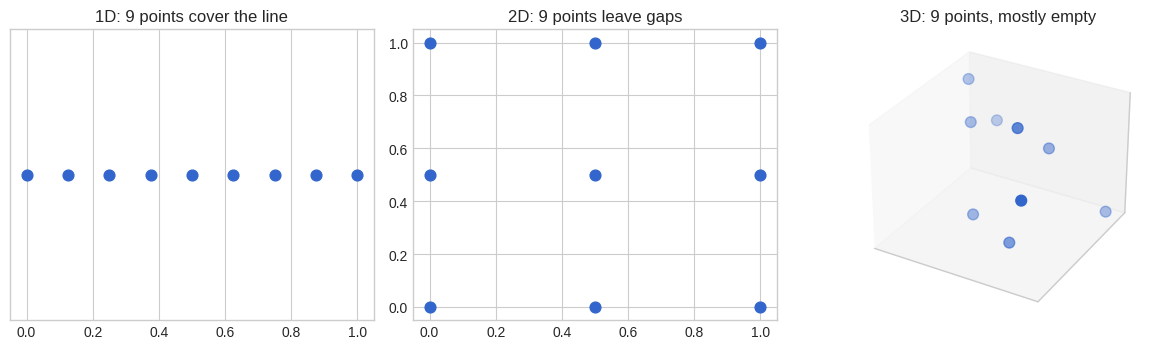

per-axis resolution N^(1/d) for N = 9 points:
  d= 1:  9^(1/1) = 9.00 points per axis
  d= 2:  9^(1/2) = 3.00 points per axis
  d= 3:  9^(1/3) = 2.08 points per axis
  d= 5:  9^(1/5) = 1.55 points per axis
  d=10:  9^(1/10) = 1.25 points per axis


In [2]:
fig = plt.figure(figsize=(12, 3.6))

# 1D: 9 points on a line
ax1 = fig.add_subplot(1, 3, 1)
pts1 = np.linspace(0, 1, 9)
ax1.scatter(pts1, np.zeros_like(pts1), s=60, color="#3366cc")
ax1.set_title("1D: 9 points cover the line"); ax1.set_yticks([]); ax1.set_xlim(-0.05,1.05)

# 2D: 3x3 grid = 9 points
ax2 = fig.add_subplot(1, 3, 2)
g = np.linspace(0, 1, 3); xx, yy = np.meshgrid(g, g)
ax2.scatter(xx.ravel(), yy.ravel(), s=60, color="#3366cc")
ax2.set_title("2D: 9 points leave gaps"); ax2.set_xlim(-0.05,1.05); ax2.set_ylim(-0.05,1.05)

# 3D: 9 random points in the cube
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
P = rng.random((9, 3))
ax3.scatter(P[:,0], P[:,1], P[:,2], s=60, color="#3366cc")
ax3.set_title("3D: 9 points, mostly empty"); ax3.set_xticks([]); ax3.set_yticks([]); ax3.set_zticks([])
plt.tight_layout(); plt.show()

print("per-axis resolution N^(1/d) for N = 9 points:")
for d in [1,2,3,5,10]:
    print(f"  d={d:2d}:  9^(1/{d}) = {9**(1/d):.2f} points per axis")

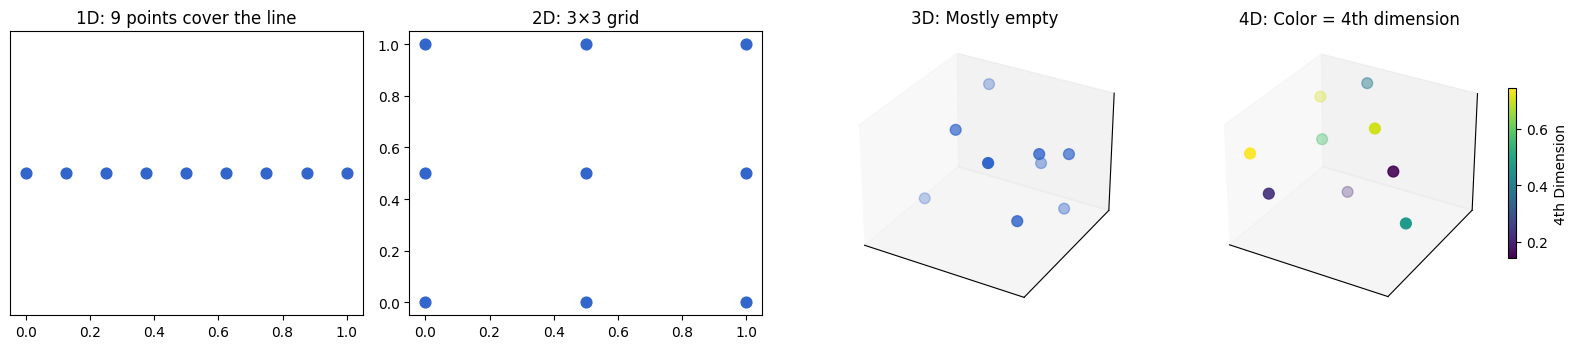

Per-axis resolution N^(1/d) for N = 9 points:
d= 1: 9^(1/1) = 9.00 points per axis
d= 2: 9^(1/2) = 3.00 points per axis
d= 3: 9^(1/3) = 2.08 points per axis
d= 4: 9^(1/4) = 1.73 points per axis
d= 5: 9^(1/5) = 1.55 points per axis
d=10: 9^(1/10) = 1.25 points per axis


In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

fig = plt.figure(figsize=(16, 3.6))

# ---------------- 1D ----------------
ax1 = fig.add_subplot(1, 4, 1)
pts1 = np.linspace(0, 1, 9)
ax1.scatter(pts1, np.zeros_like(pts1), s=60, color="#3366cc")
ax1.set_title("1D: 9 points cover the line")
ax1.set_xlim(-0.05, 1.05)
ax1.set_yticks([])

# ---------------- 2D ----------------
ax2 = fig.add_subplot(1, 4, 2)
g = np.linspace(0, 1, 3)
xx, yy = np.meshgrid(g, g)
ax2.scatter(xx.ravel(), yy.ravel(), s=60, color="#3366cc")
ax2.set_title("2D: 3×3 grid")
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)

# ---------------- 3D ----------------
ax3 = fig.add_subplot(1, 4, 3, projection="3d")
P = rng.random((9, 3))
ax3.scatter(P[:,0], P[:,1], P[:,2], s=60, color="#3366cc")
ax3.set_title("3D: Mostly empty")
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_zticks([])

# ---------------- 4D ----------------
ax4 = fig.add_subplot(1, 4, 4, projection="3d")

P4 = rng.random((9, 4))

sc = ax4.scatter(
    P4[:,0], P4[:,1], P4[:,2],
    c=P4[:,3],          # 4th dimension shown by color
    cmap="viridis",
    s=60
)

ax4.set_title("4D: Color = 4th dimension")
ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_zticks([])

# Colorbar explains the 4th dimension
cbar = plt.colorbar(sc, ax=ax4, shrink=0.6)
cbar.set_label("4th Dimension")

plt.tight_layout()
plt.show()

print("Per-axis resolution N^(1/d) for N = 9 points:")
for d in [1, 2, 3, 4, 5, 10]:
    print(f"d={d:2d}: 9^(1/{d}) = {9**(1/d):.2f} points per axis")

## 2. The spiky cube — distance to the corner grows like $\sqrt{d}$

Take the hypercube $[-1,1]^d$ centred at the origin. Each **face** stays at distance $1$ from the centre, but a **corner** $(\pm1,\dots,\pm1)$ sits at distance

$$\big\| (1,1,\dots,1) \big\|_2 = \sqrt{\underbrace{1^2+\cdots+1^2}_{d}} = \sqrt{d}.$$

**Mathematical meaning.** The faces don't move, but the corners run away as $\sqrt{d}$: in $d=100$ the corner is $10\times$ farther than the face; in $d=1000$ it is $\sqrt{1000}\approx 31.6\times$ farther. A high-dimensional cube is not "ball-like" — it is an exploding cluster of spikes, with almost all of itself far from the centre.

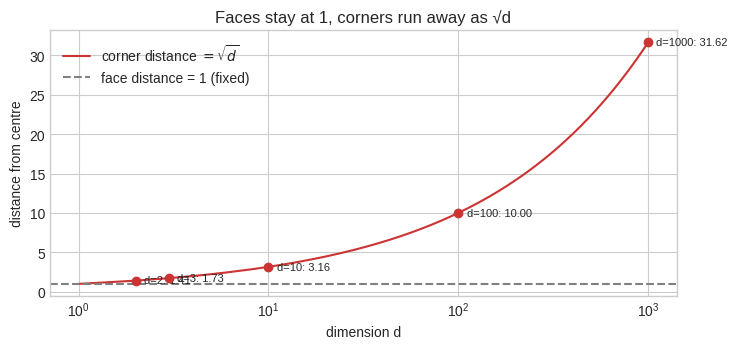

d=   2  center->corner = sqrt(d) =   1.41   (face stays at 1)
d=   3  center->corner = sqrt(d) =   1.73   (face stays at 1)
d=  10  center->corner = sqrt(d) =   3.16   (face stays at 1)
d= 100  center->corner = sqrt(d) =  10.00   (face stays at 1)
d=1000  center->corner = sqrt(d) =  31.62   (face stays at 1)


In [3]:
ds = np.arange(1, 1001)
corner = np.sqrt(ds)
plt.figure(figsize=(7.5, 3.6))
plt.plot(ds, corner, color="#cc3333", label=r"corner distance $=\sqrt{d}$")
plt.axhline(1.0, ls="--", color="gray", label="face distance = 1 (fixed)")
for d in [2,3,10,100,1000]:
    plt.scatter([d],[math.sqrt(d)], color="#cc3333", zorder=5)
    plt.annotate(f"d={d}: {math.sqrt(d):.2f}", (d, math.sqrt(d)),
                 textcoords="offset points", xytext=(6,-2), fontsize=8)
plt.xscale("log"); plt.xlabel("dimension d"); plt.ylabel("distance from centre")
plt.title("Faces stay at 1, corners run away as √d"); plt.legend(); plt.tight_layout(); plt.show()

for d in [2,3,10,100,1000]:
    print(f"d={d:4d}  center->corner = sqrt(d) = {math.sqrt(d):6.2f}   (face stays at 1)")

## 3. Volume flees to a thin shell near the surface

Compare a ball of radius $1$ with a slightly smaller ball of radius $1-\varepsilon$. The fraction of the big ball's volume lying in the outer shell of thickness $\varepsilon$ is

$$1 - \frac{\mathrm{vol}\big(\text{ball }(1-\varepsilon)\big)}{\mathrm{vol}\big(\text{ball }(1)\big)} = 1 - (1-\varepsilon)^{d}.$$

**Mathematical meaning.** Because the ratio is raised to the power $d$, even a thin rind captures *almost all* the volume as $d$ grows: for $\varepsilon=0.1$, the outer $10\%$ shell holds $65\%$ of the volume at $d=10$ and $>99\%$ by $d=50$. "Most of a high-dimensional object lives near its surface" — the inside is essentially empty.

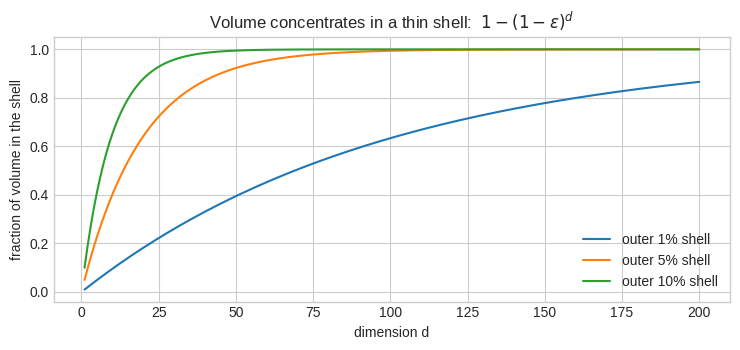

fraction of a ball's volume in its outer 10% shell:
  d=   1:  0.1000
  d=   2:  0.1900
  d=   5:  0.4095
  d=  10:  0.6513
  d=  50:  0.9948
  d= 100:  1.0000


In [4]:
ds = np.arange(1, 201)
plt.figure(figsize=(7.5, 3.6))
for eps in [0.01, 0.05, 0.1]:
    plt.plot(ds, 1-(1-eps)**ds, label=f"outer {int(eps*100)}% shell")
plt.xlabel("dimension d"); plt.ylabel("fraction of volume in the shell")
plt.title(r"Volume concentrates in a thin shell:  $1-(1-\varepsilon)^d$")
plt.legend(); plt.tight_layout(); plt.show()

print("fraction of a ball's volume in its outer 10% shell:")
for d in [1,2,5,10,50,100]:
    print(f"  d={d:4d}:  {1-0.9**d:.4f}")

## 4. The vanishing sphere — $\mathrm{vol(ball)}/\mathrm{vol(cube)} \to 0$

Inscribe the largest ball inside the unit cube of side $1$: the ball has radius $\tfrac12$. The volume of a $d$-ball of radius $r$ is

$$V_d(r) = \frac{\pi^{d/2}}{\Gamma\!\big(\tfrac{d}{2}+1\big)}\, r^{d},$$

so (the cube has volume $1$) the ratio is

$$\frac{\mathrm{vol(ball)}}{\mathrm{vol(cube)}} = \frac{\pi^{d/2}}{\Gamma\!\big(\tfrac{d}{2}+1\big)}\Big(\tfrac12\Big)^{d}.$$

**Mathematical meaning.** The $\Gamma$ function in the denominator grows faster than any exponential, so the inscribed ball fills a vanishing fraction of the cube: $78.5\%$ in 2D, $52.4\%$ in 3D, $16.4\%$ in 5D, $0.25\%$ in 10D, and effectively $0$ beyond. **All** the cube's volume ends up in the corners that the ball never reaches.

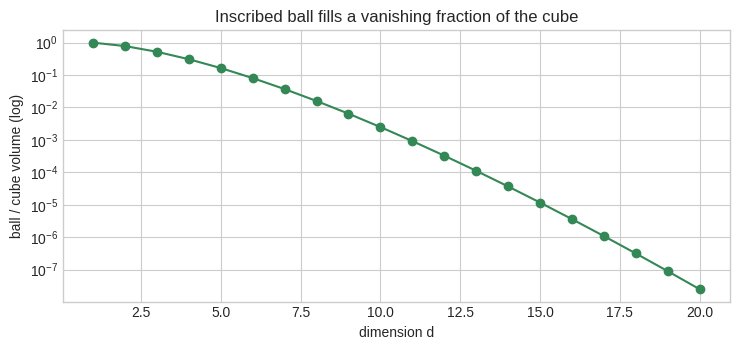

  d        ratio    percent
  2     0.785398    78.540%
  3     0.523599    52.360%
  5     0.164493    16.449%
 10     0.002490     0.249%
 20     0.000000     0.000%


In [5]:
def ball_cube_ratio(d):
    return math.pi**(d/2) / math.gamma(d/2 + 1) * (0.5)**d

ds = np.arange(1, 21)
ratios = [ball_cube_ratio(d) for d in ds]
plt.figure(figsize=(7.5, 3.6))
plt.plot(ds, ratios, "o-", color="#338855")
plt.yscale("log"); plt.xlabel("dimension d"); plt.ylabel("ball / cube volume (log)")
plt.title("Inscribed ball fills a vanishing fraction of the cube"); plt.tight_layout(); plt.show()

print(f"{'d':>3} {'ratio':>12} {'percent':>10}")
for d in [2,3,5,10,20]:
    r = ball_cube_ratio(d)
    print(f"{d:>3} {r:>12.6f} {r*100:>9.3f}%")

## 5. Exponential data hunger — $5^d$

To sample each axis at the same density of, say, $5$ levels, a grid over $d$ axes needs

$$N(d) = 5^{d} \text{ points.}$$

**Mathematical meaning.** Keeping a *constant* sampling density costs a number of points that is **exponential** in the dimension. This is the curse stated as a data-budget: $5$ points in 1D, $25$ in 2D, $125$ in 3D, but nearly $10$ **million** by $d=10$. No real dataset can keep up, so high-dimensional space is always under-sampled.

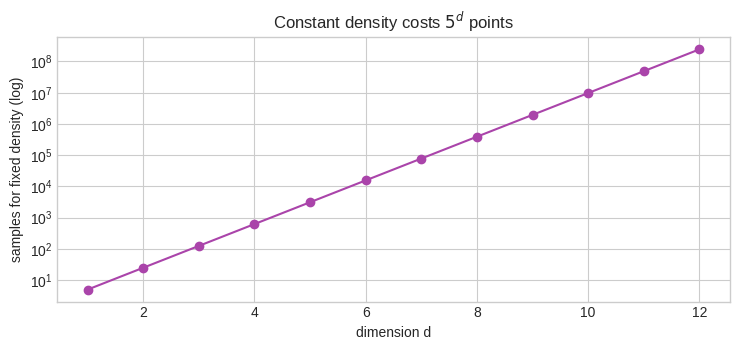

d= 1:  5^1 = 5 samples
d= 2:  5^2 = 25 samples
d= 3:  5^3 = 125 samples
d= 5:  5^5 = 3,125 samples
d=10:  5^10 = 9,765,625 samples


In [6]:
ds = np.arange(1, 13)
plt.figure(figsize=(7.5, 3.6))
plt.plot(ds, 5.0**ds, "o-", color="#aa44aa")
plt.yscale("log"); plt.xlabel("dimension d"); plt.ylabel("samples for fixed density (log)")
plt.title(r"Constant density costs $5^d$ points"); plt.tight_layout(); plt.show()
for d in [1,2,3,5,10]:
    print(f"d={d:2d}:  5^{d} = {5**d:,} samples")

## 6. Everything becomes orthogonal — $\mathbb{E}[\cos]=0,\ \mathrm{Var}=1/d$

Draw two independent random unit vectors $u,v$ in $\mathbb{R}^d$. Their cosine similarity is $u\cdot v$, and one can show

$$\mathbb{E}[\,u\cdot v\,] = 0, \qquad \mathrm{Var}(\,u\cdot v\,) = \frac{1}{d}.$$

**Mathematical meaning.** The *typical* angle between two random vectors concentrates at $90^\circ$: the spread of cosine similarity shrinks like $1/\sqrt{d}$. In high dimensions almost any two directions are **nearly perpendicular** — so "direction" carries little discriminating information, and dot-product / angle-based methods lose contrast. We verify both the mean and the $1/d$ variance empirically.

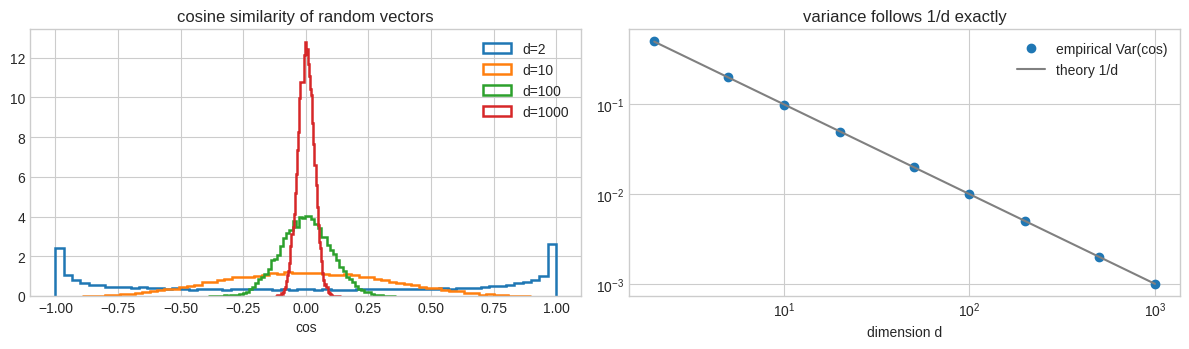

d=    2  mean(cos)=-0.0003  var(cos)=0.49635  (1/d=0.50000)
d=   10  mean(cos)=+0.0027  var(cos)=0.09889  (1/d=0.10000)
d=  100  mean(cos)=-0.0012  var(cos)=0.00993  (1/d=0.01000)


d= 1000  mean(cos)=+0.0001  var(cos)=0.00099  (1/d=0.00100)


In [7]:
def cosine_samples(d, n=20000):
    A = rng.normal(size=(n, d)); B = rng.normal(size=(n, d))
    A /= np.linalg.norm(A, axis=1, keepdims=True)
    B /= np.linalg.norm(B, axis=1, keepdims=True)
    return np.sum(A*B, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for d in [2, 10, 100, 1000]:
    c = cosine_samples(d)
    ax[0].hist(c, bins=60, density=True, histtype="step", lw=1.8, label=f"d={d}")
ax[0].set_title("cosine similarity of random vectors"); ax[0].set_xlabel("cos"); ax[0].legend()

dims = np.array([2,5,10,20,50,100,200,500,1000])
emp_var = [cosine_samples(d).var() for d in dims]
ax[1].plot(dims, emp_var, "o", label="empirical Var(cos)")
ax[1].plot(dims, 1/dims, "-", color="gray", label="theory 1/d")
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].set_xlabel("dimension d")
ax[1].set_title("variance follows 1/d exactly"); ax[1].legend()
plt.tight_layout(); plt.show()

for d in [2,10,100,1000]:
    c = cosine_samples(d)
    print(f"d={d:5d}  mean(cos)={c.mean():+.4f}  var(cos)={c.var():.5f}  (1/d={1/d:.5f})")

## 7. Distance concentration — nearest $\approx$ farthest

Pick a query point and $N$ others uniformly in $[0,1]^d$. A standard result (Beyer et al.) is that the **relative contrast** between the farthest and nearest neighbour vanishes:

$$\frac{\mathrm{dist}_{\max} - \mathrm{dist}_{\min}}{\mathrm{dist}_{\min}} \xrightarrow[d\to\infty]{} 0.$$

**Mathematical meaning.** As $d$ grows, every point ends up at almost the *same* distance from the query — the nearest and farthest neighbours become indistinguishable. This is the death of nearest-neighbour search and any distance-based method: the very notion of "closest" stops being meaningful for uniform high-dimensional data.

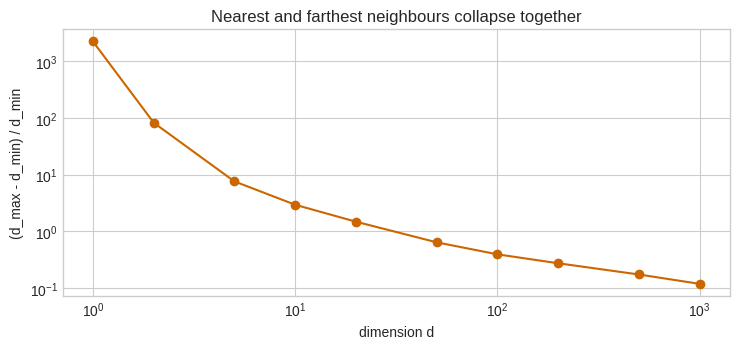

d=    1  relative contrast = 2227.478
d=    2  relative contrast =   82.139
d=    5  relative contrast =    7.628
d=   10  relative contrast =    2.949
d=   20  relative contrast =    1.480
d=   50  relative contrast =    0.643
d=  100  relative contrast =    0.394
d=  200  relative contrast =    0.274
d=  500  relative contrast =    0.174
d= 1000  relative contrast =    0.119


In [8]:
def relative_contrast(d, N=1000, q=None):
    P = rng.random((N, d)); q = rng.random((1, d)) if q is None else q
    dist = np.linalg.norm(P - q, axis=1)
    return (dist.max() - dist.min()) / dist.min()

dims = [1,2,5,10,20,50,100,200,500,1000]
rc = [np.mean([relative_contrast(d) for _ in range(5)]) for d in dims]
plt.figure(figsize=(7.5, 3.6))
plt.plot(dims, rc, "o-", color="#cc6600")
plt.xscale("log"); plt.yscale("log"); plt.xlabel("dimension d")
plt.ylabel("(d_max - d_min) / d_min"); plt.title("Nearest and farthest neighbours collapse together")
plt.tight_layout(); plt.show()
for d, r in zip(dims, rc):
    print(f"d={d:5d}  relative contrast = {r:8.3f}")

# Part II — The curse on real data (MNIST)

The geometry above assumes data spread *uniformly* through the cube. Real data is not uniform — it lives on a thin, curved, low-dimensional **manifold** inside the high-dimensional space. MNIST gives us $784$-dimensional points ($28\times28$ pixels) to test how much of the curse actually bites.

In [9]:
# Robust MNIST loader: tries several sources, falls back to sklearn's 8x8 digits.
import os, io, gzip, struct, urllib.request

def _load_idx(buf):
    data = gzip.open(io.BytesIO(buf)).read()
    magic, = struct.unpack(">I", data[:4])
    if magic == 2051:
        n, r, c = struct.unpack(">III", data[4:16])
        return np.frombuffer(data[16:], np.uint8).reshape(n, r*c)
    n, = struct.unpack(">I", data[4:8])
    return np.frombuffer(data[8:], np.uint8)

def load_mnist():
    # 1) local cache
    if os.path.exists("mnist_X.npy"):
        return np.load("mnist_X.npy")/255.0, np.load("mnist_y.npy"), "MNIST 784-d (cache)"
    # 2) sklearn openml
    try:
        from sklearn.datasets import fetch_openml
        X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
        return X/255.0, y.astype(int), "MNIST 784-d (openml)"
    except Exception:
        pass
    # 3) github mirror
    try:
        base = "https://raw.githubusercontent.com/fgnt/mnist/master/"
        Xb = urllib.request.urlopen(base+"train-images-idx3-ubyte.gz", timeout=30).read()
        yb = urllib.request.urlopen(base+"train-labels-idx1-ubyte.gz", timeout=30).read()
        return _load_idx(Xb)/255.0, _load_idx(yb), "MNIST 784-d (github)"
    except Exception:
        pass
    # 4) fallback: 8x8 digits (still a real image dataset, 64-d)
    from sklearn.datasets import load_digits
    d = load_digits()
    return d.images.reshape(len(d.images), -1)/16.0, d.target, "digits 8x8 = 64-d (fallback)"

X_full, y_full, SOURCE = load_mnist()
SIDE = int(round(math.sqrt(X_full.shape[1])))
print("loaded:", SOURCE, " shape:", X_full.shape, " image side:", SIDE)

# work on a manageable subsample
sub = rng.choice(len(X_full), min(5000, len(X_full)), replace=False)
Xm, ym = X_full[sub], y_full[sub]
print("subsample for experiments:", Xm.shape)

loaded: MNIST 784-d (cache)  shape: (60000, 784)  image side: 28
subsample for experiments: (5000, 784)


## 8. MNIST lives in $784$ dimensions

Each image is a point $x \in \mathbb{R}^{784}$ . Nominally this is a very high-dimensional space — exactly the regime where Part I says distances and angles should break down. But a digit is far from a random pixel pattern, so let us look before we conclude.

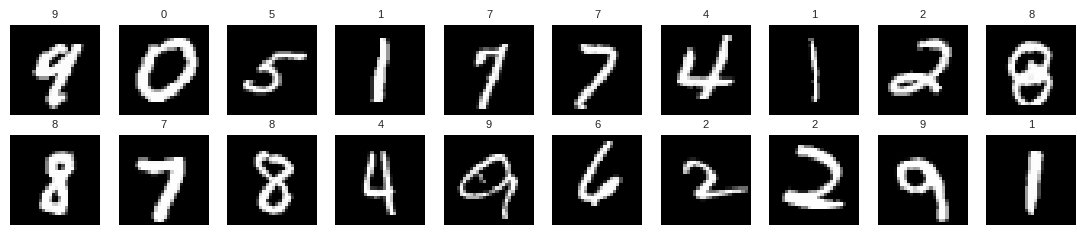

Each image is a point in R^784 — but it is a digit, not random noise.


In [10]:
sel = rng.choice(len(Xm), 20, replace=False)
fig, axes = plt.subplots(2, 10, figsize=(11, 2.4))
for ax, s in zip(axes.ravel(), sel):
    ax.imshow(Xm[s].reshape(SIDE, SIDE), cmap="gray"); ax.axis("off"); ax.set_title(str(ym[s]), fontsize=8)
plt.tight_layout(); plt.show()
print(f"Each image is a point in R^{Xm.shape[1]} — but it is a digit, not random noise.")

## 9. Random vs real — orthogonality and contrast on MNIST

Two tests from Part I, now on real data:

1. **Orthogonality.** Random $784$-d vectors have cosine similarity $\approx 0$ (variance $1/784\approx 0.0013$). Real MNIST images share ink in the same central pixels, so their pairwise cosine similarity is **far from $0$** — the manifold is not spread over all directions.
2. **Relative contrast.** For *uniform* random points contrast collapses (Section 7); for real MNIST it stays much larger, because structured data keeps near and far genuinely different.

**Mathematical meaning.** The curse is a statement about *uniform* high-dimensional data. Correlations between coordinates (here, neighbouring pixels) confine the data to a low-dimensional manifold, and on that manifold distances and angles remain informative.

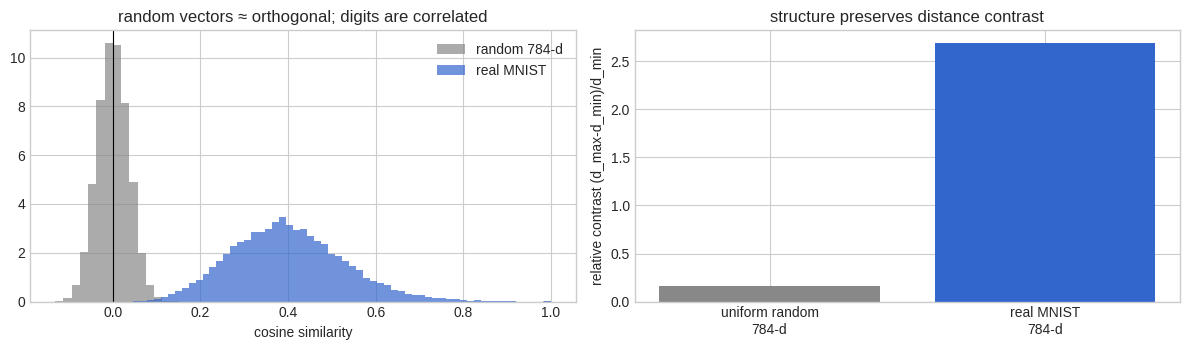

mean cosine  random 784-d : +0.000  (std 0.040, ~1/sqrt(D)=0.036)
mean cosine  real MNIST  : +0.400  (std 0.129)
relative contrast  random 784-d : 0.161
relative contrast  real MNIST   : 2.687


In [11]:
def cos_pairs(M, n=20000):
    a = M[rng.integers(len(M), size=n)]; b = M[rng.integers(len(M), size=n)]
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)
    return np.sum(a*b, axis=1)

D = Xm.shape[1]
rand_gauss = rng.normal(size=(len(Xm), D))
c_rand = cos_pairs(rand_gauss)
c_mnist = cos_pairs(Xm)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(c_rand,  bins=60, density=True, alpha=0.7, label=f"random {D}-d", color="#888888")
ax[0].hist(c_mnist, bins=60, density=True, alpha=0.7, label="real MNIST", color="#3366cc")
ax[0].axvline(0, color="k", lw=0.8); ax[0].set_xlabel("cosine similarity")
ax[0].set_title("random vectors ≈ orthogonal; digits are correlated"); ax[0].legend()

def rel_contrast(P, q):
    dist = np.linalg.norm(P - q, axis=1); return (dist.max()-dist.min())/dist.min()
qi = rng.integers(len(Xm))
rc_mnist = np.mean([rel_contrast(np.delete(Xm,qi,0), Xm[qi:qi+1]) for qi in rng.integers(len(Xm),size=5)])
R = rng.random((len(Xm), D))
rc_rand = np.mean([rel_contrast(np.delete(R,i,0), R[i:i+1]) for i in rng.integers(len(R),size=5)])
ax[1].bar(["uniform random\n%d-d" % D, "real MNIST\n%d-d" % D], [rc_rand, rc_mnist],
          color=["#888888","#3366cc"])
ax[1].set_ylabel("relative contrast (d_max-d_min)/d_min")
ax[1].set_title("structure preserves distance contrast")
plt.tight_layout(); plt.show()

print(f"mean cosine  random {D}-d : {c_rand.mean():+.3f}  (std {c_rand.std():.3f}, ~1/sqrt(D)={1/math.sqrt(D):.3f})")
print(f"mean cosine  real MNIST  : {c_mnist.mean():+.3f}  (std {c_mnist.std():.3f})")
print(f"relative contrast  random {D}-d : {rc_rand:.3f}")
print(f"relative contrast  real MNIST   : {rc_mnist:.3f}")

## 10. The escape — intrinsic dimensionality and the *blessing*

Run PCA (eigen-decomposition of the covariance, exactly as in the PCA notebook) and ask: **how many directions actually carry the variance?**

$$\Sigma = \frac{1}{m}X_c^{\top}X_c, \qquad \Sigma p_i = \lambda_i p_i, \qquad \text{cumulative variance} = \frac{\sum_{i\le k}\lambda_i}{\sum_i \lambda_i}.$$

**Mathematical meaning.** If a small $k$ already explains, say, $90\%$ of the variance, then the data's **intrinsic dimensionality** is $k \ll 784$. The points only *appear* high-dimensional; they live near a $k$-dimensional surface. This is why dimensionality reduction (PCA, UMAP), feature selection, and manifold methods work — and it is the **blessing of dimensionality**: lifting data into high dimensions can also make classes *linearly separable* that were tangled in low dimensions (the principle behind kernels and wide neural-network layers).

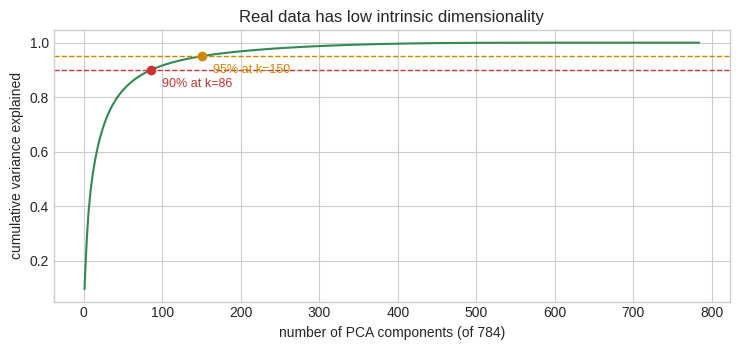

90% of variance lives in  86 / 784 directions
95% of variance lives in 150 / 784 directions
99% of variance lives in 321 / 784 directions
\n=> nominal dimension 784, but intrinsic dimension is far smaller — the curse is escapable.


In [12]:
Xc = Xm - Xm.mean(0)
cov = Xc.T @ Xc / len(Xc)
evals = np.linalg.eigvalsh(cov)[::-1]
evals = np.clip(evals, 0, None)
cum = np.cumsum(evals) / evals.sum()

plt.figure(figsize=(7.5, 3.6))
plt.plot(np.arange(1, len(cum)+1), cum, color="#338855")
for thr, col in [(0.9,"#cc3333"), (0.95,"#cc8800")]:
    k = int(np.argmax(cum >= thr) + 1)
    plt.axhline(thr, ls="--", color=col, lw=1)
    plt.scatter([k],[cum[k-1]], color=col, zorder=5)
    plt.annotate(f"{int(thr*100)}% at k={k}", (k, thr), textcoords="offset points",
                 xytext=(8,-12), fontsize=9, color=col)
plt.xlabel(f"number of PCA components (of {Xm.shape[1]})")
plt.ylabel("cumulative variance explained")
plt.title("Real data has low intrinsic dimensionality"); plt.tight_layout(); plt.show()

for thr in [0.90, 0.95, 0.99]:
    k = int(np.argmax(cum >= thr) + 1)
    print(f"{int(thr*100)}% of variance lives in {k:3d} / {Xm.shape[1]} directions")
print(f"\\n=> nominal dimension {Xm.shape[1]}, but intrinsic dimension is far smaller — the curse is escapable.")

## Summary

| effect | formula | meaning |
|---|---|---|
| spiky cube | corner $=\sqrt{d}$, face $=1$ | corners run away; cube stops being ball-like |
| thin shell | $1-(1-\varepsilon)^d \to 1$ | almost all volume sits near the surface |
| vanishing sphere | $\dfrac{\pi^{d/2}}{\Gamma(d/2+1)}(\tfrac12)^d \to 0$ | inscribed ball fills $\approx 0\%$ of the cube |
| data hunger | $5^d$ | constant density needs exponentially many points |
| orthogonality | $\mathbb{E}[\cos]=0,\ \mathrm{Var}=1/d$ | random directions are almost always perpendicular |
| distance concentration | $\dfrac{d_{\max}-d_{\min}}{d_{\min}}\to 0$ | nearest $\approx$ farthest; "closest" loses meaning |
| **MNIST reality** | intrinsic dim $\ll 784$ | structured data lives on a low-dim manifold |

**Fighting the curse:** dimensionality reduction (PCA, UMAP), feature selection, structures built for high-$d$ search (e.g. locality-sensitive hashing), regularisation, and simply collecting more data.

**The blessing:** sometimes high dimensions *help* — data not linearly separable in low dimensions can become separable once lifted, which is exactly why kernels and wide neural layers map inputs into very high-dimensional spaces before classifying.

> The curse is about *uniform* high-dimensional space. Real data is not uniform — it hides on a low-dimensional manifold, and finding that manifold is what machine learning is for.